# Simple linear regression model

1. We predict the average customer purchase income (`purchase_value`, in monetary units) based on the time spent on the site (`time_on_site`, in minutes).
2. Build a scatter plot for the input data. Assess the type of dependence, draw the regression line on the graph.
3. Split the dataset into training and test data.
4. Train a linear model on the training data and make predictions for the test data.
5. Calculate MAE, MSE, RMSE, and $R^2$ to evaluate the prediction quality on the test dataset.
6. Calculate MAE, MSE, RMSE, and $R^2$ to evaluate the prediction quality using cross-validation.
7. Draw conclusions from the obtained metric values. Consider which metric is the most indicative in this task.

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,  r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "time_on_site": [
        29.1, 24.7, 17.6, 2.8, 45.4, 31.7, 48.2, 40.5, 15.7, 30.6, 25.2, 24.3,
        42.7, 25.6, 45.0, 24.2, 24.2, 47.4, 34.5, 47.1, 30.4, 26.6, 9.5, 3.2,
        30.4, 32.4, 19.8, 41.2, 40.1, 29.0, 42.0, 29.4, 10.8, 15.0, 20.5, 15.1,
        17.8, 37.4, 24.9, 43.3, 7.4, 15.4, 23.3, 41.0, 35.6, 41.4, 18.9, 40.2,
        33.0, 3.0
    ],
    "purchase_value": [
        396.1, 318.7, 112.3, 163.4, 624.1, 378.0, 689.4, 551.3, 234.3, 413.3,
        334.9, 351.1, 512.8, 265.4, 636.4, 356.7, 251.6, 620.6, 398.5, 551.6,
        493.9, 330.9, 174.2, 7.0, 368.3, 335.4, 308.5, 567.0, 535.9, 311.0,
        584.1, 428.4, 107.3, 221.1, 264.5, 242.2, 316.1, 498.3, 323.8, 495.6,
        115.9, 132.3, 238.3, 553.2, 307.4, 494.6, 234.6, 497.5, 424.1, 164.1
    ]
}

df = pd.DataFrame(data)

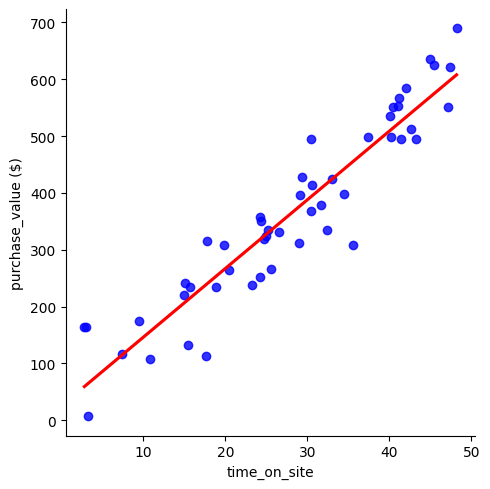

In [3]:
sns.lmplot(x="time_on_site", y="purchase_value", data=df, ci=None, line_kws={"color":"red"}, scatter_kws={"color":"blue"})

plt.xlabel("time_on_site")
plt.ylabel("purchase_value ($)")
plt.show()

Діаграма показує, що між змінними є взаємозв'язок, а саме: середній дохід від покупки клієнта залежить від часу проведеного ним на сайті.

In [4]:
X = df[["time_on_site"]]
y = df["purchase_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 9.577731734725887
Coefficient: 12.72821116844785


In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 46.23960177457298
MSE: 2991.718081214202
RMSE: 54.69660027107902
R2: 0.8859164743611154


In [7]:
mae_scores = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
mse_scores = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")

rmse_scores = np.sqrt(mse_scores)
r2_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Mean MAE:", mae_scores.mean())

print("\nMSE for each fold:", mse_scores)
print("Mean MSE:", mse_scores.mean())

print("\nRMSE for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

print("\nR2 for each fold:", r2_scores)
print("Mean R2:", r2_scores.mean())

Mean MAE: 46.518980525709935

MSE for each fold: [51.37332088 41.63502431 49.58701539 36.62543402 53.37410804]
Mean MSE: 46.518980525709935

RMSE for each fold: [7.16751846 6.45252077 7.04180484 6.05189508 7.30575855]
Mean RMSE: 6.803899540085385

R2 for each fold: [0.87353564 0.87995781 0.87713793 0.9062386  0.79112581]
Mean R2: 0.8655991582416138


Результати крос-валідації показують, що модель лінійної регресії демонструє стабільну якість передбачення. Середня абсолютна помилка становить приблизно 46 грошових одиниць, що означає, що прогнозована сума покупки відрізняється від фактичної приблизно на цю величину.